# CAVAS — Deep Learning Model Evaluation
### IDS Intrusion Detection: TabNet (Tabular) + TFT (Time Series)

**Dual prediction targets:**
- `label_generic` → Binary classification (benign / malicious)
- `Label` → Multiclass classification (benign / attack type)

**Models:**
- **TabNet** — sequential attention, native feature importance
- **Temporal Fusion Transformer (TFT)** — variable selection networks + temporal attention

**Hyperparameter tuning:** Optuna (TPE sampler)

---

### Notebook Workflow (5 steps)
1. **HPO (0.1% dataset):** Optuna hyperparameter search for TabNet & TFT — save all trial models + confusion matrices
2. **Best models & Feature Importance:** Extract best trial per model, plot feature importance
3. **Top features intersection:** Top-10 features from each model → intersection (~8–10 features)
4. **10% dataset (reduced features):** Stratified 10% sample, keep only important features
5. **Baseline training:** Retrain both models on the 10% reduced-feature dataset with optimized hyperparams

In [1]:
LOCAL_RUN = True
RANDOM_SEED = 42
RUNNINNG_ON_LINIX = True
TRIALS_ALREADY_EXECUTED = False
MIN_SAMPLES_PER_CLASS = 5
PERCENTAGE_TO_USE = 0.005  # 0.5% del dataset (stratificato per label_generic)
N_TIMESTEPS = 10           # dimensione finestra temporale per CNN-LSTM

## 0. Configuration & Setup

In [2]:
!pip install -q pytorch-tabnet pytorch-forecasting pytorch-lightning optuna optuna-integration scikit-learn pandas pyarrow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os, subprocess, warnings, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import math

# Spark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer

# Sklearn
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.metrics          import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, matthews_corrcoef
)

# TabNet — multi-task classifier (predicts both targets simultaneously)
from pytorch_tabnet.multitask import TabNetMultiTaskClassifier

# TFT — use lightning.pytorch (NOT pytorch_lightning) to match pytorch_forecasting
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data    import GroupNormalizer
from pytorch_forecasting.metrics import CrossEntropy, MultiLoss
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Optuna
import optuna
from optuna.integration import PyTorchLightningPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
pl.seed_everything(RANDOM_SEED)
print("All imports OK")

/home/cava/Documents/Repos/python/pucktrick/.venv/lib/python3.10/site-packages/pytorch_forecasting/models/base/_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42


All imports OK


In [4]:
# ─────────────────────────────────────────────────────────────────────
# CONFIGURATION — change only here
# ─────────────────────────────────────────────────────────────────────
PATH_IMG = "images"

if LOCAL_RUN:
    PATH = "DATASETS"
    N_OPTUNA_TRIALS    = 10           # 10 trials locally
    TABNET_MAX_EPOCHS  = 20
    CNN_LSTM_MAX_EPOCHS= 15
else:
    PATH = "file:///home/PuckTrickadmin/DATASETS"
    N_OPTUNA_TRIALS    = 20
    TABNET_MAX_EPOCHS  = 150
    CNN_LSTM_MAX_EPOCHS= 100

RANDOM_SEED  = 42
# Split temporale: non servono più TEST_SIZE / VAL_SIZE
# La suddivisione è deterministica: ogni 3 pacchetti → 2 train, 1 temp
# Da temp → alternato val / test (≈66.7% train, 16.7% val, 16.7% test)

os.makedirs(PATH_IMG, exist_ok=True)
os.makedirs("models",  exist_ok=True)

In [5]:
# ── Spark session (LOCAL / SERVER) ──────────────────────────────────
if LOCAL_RUN:
    if (RUNNINNG_ON_LINIX):
        java_home = os.environ.get('JAVA_HOME', '')
        if not java_home:
            try:
                java_path = subprocess.check_output(['which', 'java'], text=True).strip()
                os.environ['JAVA_HOME'] = os.path.dirname(os.path.dirname(os.path.realpath(java_path)))
            except subprocess.CalledProcessError:
                print("⚠️  Java not found — run: sudo apt install default-jdk")

        os.environ['PYSPARK_PYTHON']        = 'python3'
        os.environ['PYSPARK_DRIVER_PYTHON'] = 'python3'

        spark = SparkSession.builder \
            .appName("CAVAS_Models") \
            .master("local[*]") \
            .config("spark.driver.memory",          "24g") \
            .config("spark.driver.host",            "localhost") \
            .config("spark.ui.showConsoleProgress", "false") \
            .getOrCreate()
        
    else:
        # Forza JAVA_HOME al JRE corretto
        os.environ['JAVA_HOME'] = r"C:\Program Files\Java\jre-1.8"

        # Hadoop winutils per Windows
        os.environ['HADOOP_HOME'] = r"C:\hadoop"
        os.environ['PATH'] = os.environ.get('PATH', '') + r';C:\hadoop\bin'

        # Su Windows l'eseguibile è 'python', non 'python3'
        py = 'python' if os.name == 'nt' else 'python3'
        os.environ['PYSPARK_PYTHON']        = py
        os.environ['PYSPARK_DRIVER_PYTHON'] = py

        spark = SparkSession.builder \
            .appName("CAVAS_Models") \
            .master("local[*]") \
            .config("spark.driver.memory",          "24g") \
            .config("spark.driver.host",            "localhost") \
            .config("spark.ui.showConsoleProgress", "false") \
            .getOrCreate()
        
else:
    MASTER_URL  = "spark://10.0.1.8:7077"
    DRIVER_HOST = "10.0.1.8"

    spark = SparkSession.builder \
        .appName("CAVAS_Models") \
        .master(MASTER_URL) \
        .config("spark.submit.deployMode",      "client") \
        .config("spark.executor.instances",     "4") \
        .config("spark.executor.cores",         "4") \
        .config("spark.executor.memory",        "13g") \
        .config("spark.driver.memory",          "8g") \
        .config("spark.driver.host",            DRIVER_HOST) \
        .config("spark.driver.bindAddress",     DRIVER_HOST) \
        .config("spark.sql.shuffle.partitions", "32") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("WARN")

print(f"✅  Spark {spark.version} ready")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/06 23:36:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅  Spark 3.5.0 ready


## 0.1. Data Loading — Stratified Sample + Timestamp Cleanup

In [6]:
# ── Load parquet & filter first N_DAYS ───────────────────────────────
sdf_full = spark.read.parquet(f'{PATH}/all_elaborated.parquet')

display(sdf_full.head(5))

26/03/06 23:36:32 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[Row(Dst Port=5911.0, Protocol=6.0, Timestamp='28/02/2018 11:05:45', Flow Duration=2.0, Tot Fwd Pkts=1.0, Tot Bwd Pkts=1.0, TotLen Fwd Pkts=0.0, Fwd Pkt Len Max=0.0, Fwd Pkt Len Min=0.0, Bwd Pkt Len Max=0.0, Bwd Pkt Len Min=0.0, Bwd Pkt Len Mean=0.0, Flow Byts/s=0.0, Flow Pkts/s=1000000.0, Flow IAT Mean=2.0, Flow IAT Std=0.0, Bwd IAT Tot=0.0, Bwd IAT Mean=0.0, Bwd IAT Std=0.0, Fwd PSH Flags=0.0, Fwd URG Flags=0.0, Fwd Pkts/s=500000.0, Bwd Pkts/s=500000.0, Pkt Len Var=0.0, FIN Flag Cnt=0.0, RST Flag Cnt=0.0, PSH Flag Cnt=1.0, ACK Flag Cnt=0.0, URG Flag Cnt=0.0, Down/Up Ratio=1.0, Init Fwd Win Byts=1024.0, Init Bwd Win Byts=0.0, Fwd Seg Size Min=24.0, Active Mean=0.0, Active Std=0.0, Idle Min=0.0, Label='Benign', label_generic=0),
 Row(Dst Port=722.0, Protocol=6.0, Timestamp='28/02/2018 02:37:50', Flow Duration=2.0, Tot Fwd Pkts=1.0, Tot Bwd Pkts=1.0, TotLen Fwd Pkts=0.0, Fwd Pkt Len Max=0.0, Fwd Pkt Len Min=0.0, Bwd Pkt Len Max=0.0, Bwd Pkt Len Min=0.0, Bwd Pkt Len Mean=0.0, Flow Byts/s

In [7]:
# ── Cast colonne numeriche a double e Timestamp a TimestampType ───────
STRING_COLS = {'Label', 'label_generic'}   # label_generic è 0/1 ma verrà castato dopo

# 1. Timestamp: stringa DD/MM/YYYY HH:mm:ss → TimestampType
ts_dtype = dict(sdf_full.dtypes).get('Timestamp', 'string')
print(f"📅  Timestamp column type (raw): {ts_dtype}")

if ts_dtype == 'string':
    sdf_full = sdf_full.withColumn(
        'Timestamp',
        F.to_timestamp(F.col('Timestamp'), 'dd/MM/yyyy HH:mm:ss')
    )
    print("   → Convertito Timestamp string → TimestampType  (formato dd/MM/yyyy HH:mm:ss)")

# 2. Tutte le altre colonne (tranne Label, label_generic, Timestamp) → DoubleType
numeric_cols = [c for c in sdf_full.columns if c not in STRING_COLS and c != 'Timestamp']
for c in numeric_cols:
    dtype = dict(sdf_full.dtypes)[c]
    if dtype not in ('double', 'float'):
        sdf_full = sdf_full.withColumn(c, F.col(c).cast('double'))

print(f"✅  Cast completato: {len(numeric_cols)} colonne → double, Timestamp → timestamp")

# ── Rimuovi righe con anno 1970 (epoch fallback / dati corrotti) ─────
n_before = sdf_full.count()
sdf_full = sdf_full.filter(F.year(F.col('Timestamp')) > 1970)
n_after = sdf_full.count()
n_dropped = n_before - n_after
if n_dropped > 0:
    print(f"🗑️  Rimosse {n_dropped:,} righe con anno 1970 (timestamp corrotti)")
else:
    print("✅  Nessuna riga con anno 1970 trovata")

# ── Campionamento stratificato ───────────────────────────────────────
# Mantiene la stessa distribuzione di label_generic del dataset originale
if PERCENTAGE_TO_USE < 1.0:
    fractions = {
        row['label_generic']: PERCENTAGE_TO_USE
        for row in sdf_full.select('label_generic').distinct().collect()
    }
    sdf = sdf_full.sampleBy('label_generic', fractions=fractions, seed=RANDOM_SEED)
    print(f"📦  Stratified {PERCENTAGE_TO_USE*100:.1f}% sample → {sdf.count():,} righe")
else:
    sdf = sdf_full
    print(f"📦  Full dataset → {sdf.count():,} righe")

# ── Sort by Timestamp (ordine temporale per lo split successivo) ─────
sdf = sdf.orderBy('Timestamp')

print(f"🧮  Colonne: {len(sdf.columns)}")

FEATURE_NAMES = list(sdf.columns)

📅  Timestamp column type (raw): string
   → Convertito Timestamp string → TimestampType  (formato dd/MM/yyyy HH:mm:ss)
✅  Cast completato: 35 colonne → double, Timestamp → timestamp
🗑️  Rimosse 14 righe con anno 1970 (timestamp corrotti)
📦  Stratified 0.5% sample → 80,789 righe
🧮  Colonne: 38


## 0.2. Preprocessing — Normalization & Encoding

In [8]:
# ── Feature metadata from analysis ──────────────────────────────────
# Features ordered by relevance from your CSV exports

# Feature types from your analysis
CATEGORICAL_FEATURES = ['Fwd Seg Size Min', 'Protocol']
BINARY_FEATURES      = ['FIN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'Fwd URG Flag', 'Fwd PSH Flag']

# All features used for modelling
ALL_FEATURES = sdf_full.columns

# ✅ corretto
EXCLUDE_FROM_FEATURES = {'Label', 'label_generic', 'Timestamp'}

ALL_FEATURES = [c for c in sdf_full.columns if c not in EXCLUDE_FROM_FEATURES]

CONTINUOUS_FEATURES = [
    f for f in ALL_FEATURES
    if f not in CATEGORICAL_FEATURES and f not in BINARY_FEATURES
]

# Verify all expected features exist in the dataset
available = set(sdf.columns)
missing   = [f for f in ALL_FEATURES if f not in available]
if missing:
    print(f"⚠️  Missing features in dataset: {missing}")
    ALL_FEATURES = [f for f in ALL_FEATURES if f not in missing]
else:
    print(f"✅  All {len(ALL_FEATURES)} features found in dataset")

✅  All 35 features found in dataset


In [9]:
def label_encoding_spark(sdf):
    """Add label_generic_enc (0/1) and Label_enc (integer) to the Spark DataFrame.
    Returns (sdf_encoded, label_classes) where label_classes maps index → Label name.
    """
    # ── Binary: label_generic is already 0/1 → cast to int ──────────
    sdf = sdf.withColumn('label_generic_enc', col('label_generic').cast('int'))

    # ── Multiclass: Label → integer index via StringIndexer ──────────
    indexer = StringIndexer(inputCol='Label', outputCol='Label_enc', handleInvalid='keep')
    model = indexer.fit(sdf)
    sdf = model.transform(sdf)
    sdf = sdf.withColumn('Label_enc', col('Label_enc').cast('int'))

    # Store ordered label list: index 0 → labels[0], etc.
    label_classes = list(model.labels)

    n_binary = sdf.select('label_generic_enc').distinct().count()
    print(f"✅  label_generic_enc: {n_binary} classes | Label_enc: {len(label_classes)} classes")
    print(f"    Label mapping: { {i: l for i, l in enumerate(label_classes)} }")
    return sdf, label_classes

In [10]:
def preprocess_to_pandas(sdf, continuous_features, categorical_features, binary_features):
    """
    Convert Spark → Pandas and clean dtypes.
    
    - Continuous: cast to float64 (scaling done AFTER train/test split to avoid leakage)
    - Categorical: integer-encoded via LabelEncoder (TabNet/TFT handle them natively)
    - Binary: cast to int
    
    ⚠ NO one-hot encoding:
      • TabNet uses cat_idxs / cat_dims natively
      • TFT uses time_varying_known_categoricals
      • Feature importance stays traceable to the original feature name
    """
    print("⏳  Converting Spark → Pandas ...")
    pdf = sdf.toPandas()
    print(f"📊  Shape: {pdf.shape}")

    available = set(pdf.columns)
    cont_cols = [c for c in continuous_features if c in available]
    cat_cols  = [c for c in categorical_features if c in available]
    bin_cols  = [c for c in binary_features if c in available]

    # ── Continuous → float64 ──────────────────────────────────────────
    for c in cont_cols:
        pdf[c] = pd.to_numeric(pdf[c], errors='coerce')
    pdf[cont_cols] = pdf[cont_cols].fillna(0.0)

    # ── Categorical → integer codes ──────────────────────────────────
    cat_encoders = {}
    cat_dims = {}
    for c in cat_cols:
        le = LabelEncoder()
        pdf[c] = le.fit_transform(pdf[c].astype(str))
        cat_encoders[c] = le
        cat_dims[c] = len(le.classes_)

    # ── Binary → int ─────────────────────────────────────────────────
    for c in bin_cols:
        pdf[c] = pd.to_numeric(pdf[c], errors='coerce').fillna(0).astype(int)

    print(f"✅  Preprocessed: {len(cont_cols)} continuous | {len(cat_cols)} categorical | {len(bin_cols)} binary")
    return pdf, cat_encoders, cat_dims

In [11]:
if TRIALS_ALREADY_EXECUTED:
    aaaaaaaaaaaaaaaaaaaaa # stop the notebook here, trials already executed

In [12]:
# ── Preprocess & cache (Pandas-based, fast) ──────────────────────────
pct_label = f"{PERCENTAGE_TO_USE*100:.1f}pct".replace('.', '_')
PREPROCESSED_PATH = f"{PATH}/preprocessed_model_{pct_label}.parquet"

if os.path.exists(PREPROCESSED_PATH):
    pdf_encoded = pd.read_parquet(PREPROCESSED_PATH)

    # Rebuild metadata from cached file
    EXCLUDE = {'Label', 'label_generic', 'Label_enc', 'label_generic_enc', 'Timestamp'}
    FINAL_FEATURES = [c for c in pdf_encoded.columns if c not in EXCLUDE]

    # Recover label_classes mapping from data
    _lbl_map = (pdf_encoded[['Label', 'Label_enc']]
                .drop_duplicates()
                .sort_values('Label_enc')
                .set_index('Label_enc')['Label']
                .to_dict())
    label_classes = [_lbl_map[i] for i in range(len(_lbl_map))]

    # Categorical metadata for TabNet
    CAT_FEATURE_NAMES = [c for c in CATEGORICAL_FEATURES if c in FINAL_FEATURES]
    CAT_IDXS = [FINAL_FEATURES.index(c) for c in CAT_FEATURE_NAMES]
    CAT_DIMS = [int(pdf_encoded[c].nunique()) for c in CAT_FEATURE_NAMES]

    print(f"✅  Cache loaded: {len(pdf_encoded):,} rows, {len(FINAL_FEATURES)} features")
else:
    print("⚠️  No cache found — running preprocessing ...")
    sdf_enc, label_classes = label_encoding_spark(sdf)
    pdf_encoded, cat_encoders, cat_dims_dict = preprocess_to_pandas(
        sdf_enc, CONTINUOUS_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES
    )

    EXCLUDE = {'Label', 'label_generic', 'Label_enc', 'label_generic_enc', 'Timestamp'}
    FINAL_FEATURES = [c for c in pdf_encoded.columns if c not in EXCLUDE]
    CAT_FEATURE_NAMES = [c for c in CATEGORICAL_FEATURES if c in FINAL_FEATURES]
    CAT_IDXS = [FINAL_FEATURES.index(c) for c in CAT_FEATURE_NAMES]
    CAT_DIMS = [cat_dims_dict[c] for c in CAT_FEATURE_NAMES]

    pdf_encoded.to_parquet(PREPROCESSED_PATH, index=False)
    print(f"💾  Saved to {PREPROCESSED_PATH}")

# ── Global counters ──────────────────────────────────────────────────
n_classes_multi = len(label_classes)

print(f"\n🧮  Features: {len(FINAL_FEATURES)} | Binary classes: 2 | Multi classes: {n_classes_multi}")
print(f"📌  Label mapping: { {i: l for i, l in enumerate(label_classes)} }")
if CAT_IDXS:
    print(f"📌  Categorical for TabNet: {list(zip(CAT_FEATURE_NAMES, CAT_IDXS, CAT_DIMS))}")
else:
    print("📌  No categorical features detected in final feature set")

⚠️  No cache found — running preprocessing ...
✅  label_generic_enc: 2 classes | Label_enc: 13 classes
    Label mapping: {0: 'Benign', 1: 'DDOS attack-HOIC', 2: 'DDoS attacks-LOIC-HTTP', 3: 'DoS attacks-Hulk', 4: 'Bot', 5: 'SSH-Bruteforce', 6: 'FTP-BruteForce', 7: 'Infilteration', 8: 'DoS attacks-SlowHTTPTest', 9: 'DoS attacks-GoldenEye', 10: 'DoS attacks-Slowloris', 11: 'DDOS attack-LOIC-UDP', 12: 'Brute Force -Web'}
⏳  Converting Spark → Pandas ...
📊  Shape: (80789, 40)
✅  Preprocessed: 28 continuous | 2 categorical | 5 binary
💾  Saved to DATASETS/preprocessed_model_0_5pct.parquet

🧮  Features: 35 | Binary classes: 2 | Multi classes: 13
📌  Label mapping: {0: 'Benign', 1: 'DDOS attack-HOIC', 2: 'DDoS attacks-LOIC-HTTP', 3: 'DoS attacks-Hulk', 4: 'Bot', 5: 'SSH-Bruteforce', 6: 'FTP-BruteForce', 7: 'Infilteration', 8: 'DoS attacks-SlowHTTPTest', 9: 'DoS attacks-GoldenEye', 10: 'DoS attacks-Slowloris', 11: 'DDOS attack-LOIC-UDP', 12: 'Brute Force -Web'}
📌  Categorical for TabNet: [('Fwd

In [13]:
# ── Diagnostica: cosa c'è davvero nel dataframe? ─────────────────────
print("\nTutte le colonne nel pdf_encoded:")
for i, c in enumerate(pdf_encoded.columns):
    is_in_exclude = c in EXCLUDE
    is_in_final = c in FINAL_FEATURES
    print(f"  {i:2d}. '{c}' → EXCLUDE={is_in_exclude}, FINAL={is_in_final}")

print(f"\nTotal columns: {len(pdf_encoded.columns)}")
print(f"FINAL_FEATURES: {len(FINAL_FEATURES)}")
print(f"EXCLUDE matches: {[c for c in pdf_encoded.columns if c in EXCLUDE]}")
print(f"NOT excluded but look like targets: {[c for c in FINAL_FEATURES if 'label' in c.lower() or 'Label' in c]}")


Tutte le colonne nel pdf_encoded:
   0. 'Dst Port' → EXCLUDE=False, FINAL=True
   1. 'Protocol' → EXCLUDE=False, FINAL=True
   2. 'Timestamp' → EXCLUDE=True, FINAL=False
   3. 'Flow Duration' → EXCLUDE=False, FINAL=True
   4. 'Tot Fwd Pkts' → EXCLUDE=False, FINAL=True
   5. 'Tot Bwd Pkts' → EXCLUDE=False, FINAL=True
   6. 'TotLen Fwd Pkts' → EXCLUDE=False, FINAL=True
   7. 'Fwd Pkt Len Max' → EXCLUDE=False, FINAL=True
   8. 'Fwd Pkt Len Min' → EXCLUDE=False, FINAL=True
   9. 'Bwd Pkt Len Max' → EXCLUDE=False, FINAL=True
  10. 'Bwd Pkt Len Min' → EXCLUDE=False, FINAL=True
  11. 'Bwd Pkt Len Mean' → EXCLUDE=False, FINAL=True
  12. 'Flow Byts/s' → EXCLUDE=False, FINAL=True
  13. 'Flow Pkts/s' → EXCLUDE=False, FINAL=True
  14. 'Flow IAT Mean' → EXCLUDE=False, FINAL=True
  15. 'Flow IAT Std' → EXCLUDE=False, FINAL=True
  16. 'Bwd IAT Tot' → EXCLUDE=False, FINAL=True
  17. 'Bwd IAT Mean' → EXCLUDE=False, FINAL=True
  18. 'Bwd IAT Std' → EXCLUDE=False, FINAL=True
  19. 'Fwd PSH Flags' → EXCL

### 2.1 Prepare arrays & Temporal Split

**Strategia di split temporale (preserva ordine cronologico):**
1. Dati ordinati per `Timestamp` (primi `N_DAYS` giorni)
2. Ogni 3 pacchetti consecutivi → **2 train**, **1 temp**
3. Da temp → alternato **val** / **test**

| Split | % approx | Descrizione |
|-------|----------|-------------|
| Train | ~66.7% | Pacchetti in posizione 0, 1 di ogni tripla |
| Val   | ~16.7% | Pacchetti temp pari |
| Test  | ~16.7% | Pacchetti temp dispari |

**TabNet:** array 2D `(n_samples, n_features)` — split a livello di riga
**CNN-LSTM:** array 3D `(n_windows, N_TIMESTEPS, n_features)` — sliding windows + split a livello di finestra

In [14]:
# ── Sort by Timestamp per mantenere l'ordine temporale ────────────────
if 'Timestamp' in pdf_encoded.columns:
    pdf_encoded = pdf_encoded.sort_values('Timestamp').reset_index(drop=True)
    print("✅  pdf_encoded ordinato per Timestamp")

# ── Data is already in Pandas from preprocessing ─────────────────────
X = pdf_encoded[FINAL_FEATURES].values.astype(np.float64)  # float64 first to detect issues
y_binary = pdf_encoded['label_generic_enc'].values.astype(int)
y_multi  = pdf_encoded['Label_enc'].values.astype(int)

# ── Clean inf / extreme values ───────────────────────────────────────
n_inf = np.isinf(X).sum()
n_nan = np.isnan(X).sum()
if n_inf > 0 or n_nan > 0:
    print(f"⚠️  Found {n_inf} inf and {n_nan} NaN values → replacing with 0")
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Clip extreme outliers that overflow float32 range
f32_max = np.finfo(np.float32).max
n_clipped = (np.abs(X) > f32_max).sum()
if n_clipped > 0:
    print(f"⚠️  Clipping {n_clipped} values exceeding float32 range")
    X = np.clip(X, -f32_max, f32_max)

X = X.astype(np.float32)

print(f"📊  X shape: {X.shape}")
print(f"    y_binary: {np.unique(y_binary, return_counts=True)}")
print(f"    y_multi:  {len(np.unique(y_multi))} classes (n_classes_multi={n_classes_multi})")

✅  pdf_encoded ordinato per Timestamp
📊  X shape: (80789, 35)
    y_binary: (array([0, 1]), array([66934, 13855]))
    y_multi:  13 classes (n_classes_multi=13)


In [15]:
# ── Unified TEMPORAL split — preserva ordine cronologico ──────────────
# Strategia: ogni 3 pacchetti consecutivi →  2 train, 1 temp
#            da temp → alternato val / test
# Risultato ≈ 66.7% train | 16.7% val | 16.7% test

# ── 1. Filtra classi rare ────────────────────────────────────────────
classes, counts = np.unique(y_multi, return_counts=True)
rare_classes    = classes[counts < MIN_SAMPLES_PER_CLASS]

if len(rare_classes) > 0:
    rare_labels = [label_classes[c] for c in rare_classes]
    print(f"⚠️  Dropping {len(rare_classes)} rare classes (< {MIN_SAMPLES_PER_CLASS} samples):")
    for lbl, cnt in zip(rare_labels, counts[counts < MIN_SAMPLES_PER_CLASS]):
        print(f"    '{lbl}': {cnt} sample(s)")
    keep_mask = ~np.isin(y_multi, rare_classes)
else:
    keep_mask = np.ones(len(y_multi), dtype=bool)
    print("✅  All multiclass labels have enough samples")

X_clean      = X[keep_mask]
y_bin_clean  = y_binary[keep_mask]
y_mul_clean  = y_multi[keep_mask]
n_classes_multi = len(np.unique(y_mul_clean))

print(f"\nDataset dopo filtering: {len(X_clean):,} righe")

# ── 2. Split temporale a livello di pacchetto (riga) ─────────────────
# I dati sono già ordinati per Timestamp.
n_total      = len(X_clean)
packet_group = np.arange(n_total) % 3

train_mask = packet_group < 2       # posizioni 0, 1 → train
temp_mask  = packet_group == 2      # posizione 2 → temp

# Da temp → alternato val / test
temp_indices = np.where(temp_mask)[0]
val_indices  = temp_indices[0::2]   # pacchetti temp pari  → val
test_indices = temp_indices[1::2]   # pacchetti temp dispari → test

val_mask  = np.zeros(n_total, dtype=bool)
test_mask = np.zeros(n_total, dtype=bool)
val_mask[val_indices]   = True
test_mask[test_indices] = True

# ── 3. Scale continuous features (fit su train only — no leakage) ────
cont_idxs = [FINAL_FEATURES.index(c) for c in CONTINUOUS_FEATURES if c in FINAL_FEATURES]
scaler = StandardScaler()
scaler.fit(X_clean[train_mask][:, cont_idxs])
X_clean[:, cont_idxs] = scaler.transform(X_clean[:, cont_idxs])

# ── 4. Array 2D per TabNet ──────────────────────────────────────────
X_train   = X_clean[train_mask]
X_val     = X_clean[val_mask]
X_te      = X_clean[test_mask]

y_tr_bin  = y_bin_clean[train_mask]
y_tr_mul  = y_mul_clean[train_mask]
y_val_bin = y_bin_clean[val_mask]
y_val_mul = y_mul_clean[val_mask]
y_te_bin  = y_bin_clean[test_mask]
y_te_mul  = y_mul_clean[test_mask]

# ── 5. Finestre temporali 3D per CNN-LSTM ────────────────────────────
def create_temporal_windows(X, y_bin, y_mul, window_size):
    """Sliding windows da dati ordinati temporalmente.
    Ogni finestra: (window_size, n_features). Label = ultimo timestep."""
    n = len(X) - window_size + 1
    if n <= 0:
        raise ValueError(f"Dati insufficienti ({len(X)}) per window_size={window_size}")
    X_w     = np.array([X[i:i+window_size] for i in range(n)])
    y_bin_w = y_bin[window_size - 1:]
    y_mul_w = y_mul[window_size - 1:]
    return X_w, y_bin_w, y_mul_w

X_windows, y_bin_win, y_mul_win = create_temporal_windows(
    X_clean, y_bin_clean, y_mul_clean, N_TIMESTEPS
)

# Stesso split temporale applicato alle finestre
n_win     = len(X_windows)
win_group = np.arange(n_win) % 3

train_w = win_group < 2
temp_w  = win_group == 2

temp_w_idx = np.where(temp_w)[0]
val_w_idx  = temp_w_idx[0::2]
test_w_idx = temp_w_idx[1::2]

val_w  = np.zeros(n_win, dtype=bool)
test_w = np.zeros(n_win, dtype=bool)
val_w[val_w_idx]   = True
test_w[test_w_idx] = True

X_train_cnn   = X_windows[train_w]
X_val_cnn     = X_windows[val_w]
X_test_cnn    = X_windows[test_w]

y_tr_bin_cnn  = y_bin_win[train_w]
y_tr_mul_cnn  = y_mul_win[train_w]
y_val_bin_cnn = y_bin_win[val_w]
y_val_mul_cnn = y_mul_win[val_w]
y_te_bin_cnn  = y_bin_win[test_w]
y_te_mul_cnn  = y_mul_win[test_w]

# ── Summary ──────────────────────────────────────────────────────────
print(f"\n📊  TabNet  (2D) — Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_te):,}")
print(f"📊  CNN-LSTM (3D, window={N_TIMESTEPS}) — Train: {len(X_train_cnn):,} | Val: {len(X_val_cnn):,} | Test: {len(X_test_cnn):,}")
print(f"    X_train_cnn shape: {X_train_cnn.shape}")
print(f"Binary classes: 2 | Multiclass classes: {n_classes_multi}")
print(f"Scaled {len(cont_idxs)} continuous features")

⚠️  Dropping 1 rare classes (< 5 samples):
    'Brute Force -Web': 1 sample(s)

Dataset dopo filtering: 80,788 righe

📊  TabNet  (2D) — Train: 53,859 | Val: 13,465 | Test: 13,464
📊  CNN-LSTM (3D, window=10) — Train: 53,853 | Val: 13,463 | Test: 13,463
    X_train_cnn shape: (53853, 10, 35)
Binary classes: 2 | Multiclass classes: 12
Scaled 28 continuous features


## Step 1: Hyperparameter Optimization (0.1% Dataset)

Both models are tuned via Optuna on a 0.1% stratified sample.  
Each trial's model is stored in memory along with confusion matrices for both targets.

### Step 1.0. Utility functions

In [16]:
# ── Utility function for metrics ─────────────────────────────────────
def print_metrics(y_true, y_pred, y_proba, task_name, class_names=None, verbose=1):
    is_binary = (len(np.unique(y_true)) == 2)
    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='binary' if is_binary else 'macro')
    try:
        auc = roc_auc_score(
            y_true,
            y_proba[:, 1] if is_binary else y_proba,
            multi_class='ovr' if not is_binary else 'raise'
        )
    except Exception:
        auc = float('nan')

    if verbose != 0:
        print(f"\n{'='*55}")
        print(f"  {task_name}")
        print(f"{'='*55}")
        print(f"  Accuracy : {acc:.4f}  |  F1: {f1:.4f}  |  MCC: {mcc:.4f}  |  AUC: {auc:.4f}")
    present_labels = sorted(np.unique(np.concatenate([np.unique(y_true), np.unique(y_pred)])))
    if class_names is not None:
        target_names_filtered = [class_names[i] for i in present_labels if i < len(class_names)]
    else:
        target_names_filtered = None
    if verbose != 0:
        print(classification_report(y_true, y_pred, labels=present_labels,
                                    target_names=target_names_filtered))
    return dict(task=task_name, accuracy=acc, f1=f1, mcc=mcc, auc=auc)

In [17]:
# ── Utility: show stored model report ─────────────────────────────────
def show_model_report(model_name, artifacts_dict=None):
    """
    Display confusion matrices + key metrics for a previously-run trial.
    
    Parameters
    ----------
    model_name : str or int
        The key used in tabnet_trial_artifacts / tft_trial_artifacts,
        e.g. trial number (int) or 'Baseline' / 'TFT_Baseline' (str).
    artifacts_dict : dict, optional
        If provided, look up model_name in this dict directly.
        Otherwise tries tabnet_trial_artifacts first, then tft_trial_artifacts.
    """
    # ── Locate the artifact ───────────────────────────────────────────
    art = None
    if artifacts_dict is not None:
        art = artifacts_dict.get(model_name)
    else:
        art = tabnet_trial_artifacts.get(model_name) or cnn_lstm_trial_artifacts.get(model_name)

    if art is None:
        # Try loading from JSON on disk
        for prefix in ['tabnet_trial_', 'cnn_lstm_trial_']:
            path = f'models/{prefix}{model_name}_artifacts.json'
            if os.path.exists(path):
                with open(path) as f:
                    art = json.load(f)
                break
    if art is None:
        print(f"❌  No artifacts found for '{model_name}'")
        return

    model_type = art.get('model_type', 'Unknown')
    label      = art.get('label', str(model_name))

    print(f"\n{'='*60}")
    print(f"  📊  Report: {model_type} — {label}")
    print(f"{'='*60}")

    # ── Scalar metrics ────────────────────────────────────────────────
    for task_key, task_label in [('metrics_binary', 'Binary Task'),
                                  ('metrics_multiclass', 'Multiclass Task')]:
        m = art.get(task_key)
        if m is None:
            print(f"\n  ⚠️  {task_label}: metrics not available")
            continue
        print(f"\n  {task_label}:")
        print(f"    Accuracy : {m['accuracy']:.4f}")
        print(f"    F1-score : {m['f1']:.4f}")
        print(f"    MCC      : {m['mcc']:.4f}")
        print(f"    AUC      : {m['auc']:.4f}")

    # ── Extra scalars (model-specific) ────────────────────────────────
    if 'mean_mcc' in art:
        print(f"\n  Mean MCC (binary+multi): {art['mean_mcc']:.4f}")
    if 'val_loss' in art:
        print(f"  Val loss: {art['val_loss']:.4f}")

    # ── Confusion matrices ────────────────────────────────────────────
    cm_bin = art.get('cm_bin')
    cm_mul = art.get('cm_mul')

    if cm_bin is None and cm_mul is None:
        print("\n  ⚠️  No confusion matrices available for this trial")
        return

    # Convert from list-of-lists (JSON) back to ndarray if needed
    if cm_bin is not None and not isinstance(cm_bin, np.ndarray):
        cm_bin = np.array(cm_bin)
    if cm_mul is not None and not isinstance(cm_mul, np.ndarray):
        cm_mul = np.array(cm_mul)

    n_plots = (cm_bin is not None) + (cm_mul is not None)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    idx = 0
    if cm_bin is not None:
        sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{label} — Binary CM')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
        idx += 1

    if cm_mul is not None:
        sns.heatmap(cm_mul, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{label} — Multiclass CM')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()
    print(f"\n  Params: {json.dumps(art.get('params', {}), indent=4)}")
    
    # ── Feature importance ────────────────────────────────────────────
    fi = art.get('feature_importance')
    if fi:
        fi_sorted = dict(sorted(fi.items(), key=lambda x: x[1], reverse=True))
        top_n = dict(list(fi_sorted.items())[:20])  # top 20

        print(f"\n  Top feature importances (top {len(top_n)}):")
        fig_fi, ax_fi = plt.subplots(figsize=(8, max(3, len(top_n) * 0.35)))
        ax_fi.barh(list(top_n.keys())[::-1], list(top_n.values())[::-1], color='steelblue')
        ax_fi.set_xlabel('Importance')
        ax_fi.set_title(f'{label} — Feature Importance')
        plt.tight_layout()
        plt.show()
    else:
        print("\n  ⚠️  Feature importance not available for this trial")

In [18]:
def json_serializer(x):
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (np.floating, np.integer)):
        return None if np.isnan(x) else x.item()
    if isinstance(x, float) and np.isnan(x):
        return None  # NaN → null in JSON
    return str(x)

### Step 1a — TabNet Hyperparameter Tuning (Optuna)

**Key TabNet hyperparameters:**
| Param | Meaning |
|---|---|
| `N_a` / `N_d` | Width of attention + decision steps (usually equal) |
| `N_steps` | Number of sequential attention steps |
| `gamma` | Sparsity regularisation coefficient |
| `lambda_sparse` | Feature sparsity penalty |
| `lr` | Learning rate |

Each trial's model, confusion matrices (binary + multiclass), and metrics are saved in memory.

In [19]:
tabnet_trial_artifacts = {}

In [20]:
# ── Global storage for TabNet trial artifacts ─────────────────────────
def tabnet_multitask_objective(X_train, X_val,
                                y_tr_bin, y_tr_mul,
                                y_val_bin, y_val_mul,
                                N_a, N_steps, gamma, lambda_s, lr, batch_sz, mask_type,
                                verbose=0, trial=None, label_model=None,
                                feature_names=None):
    """
    Stores model + confusion matrices in memory for each trial.
    Returns mean MCC across both tasks on validation set.
    """
    ## Usa solo una delle due etichette per identificare il trial (label_model se fornita, altrimenti trial.number)
    FINAL_LABEL = label_model if label_model is not None else trial.number
    
    clf = TabNetMultiTaskClassifier(
        n_d=N_a, n_a=N_a,
        n_steps=N_steps,
        gamma=gamma,
        lambda_sparse=lambda_s,
        cat_idxs=CAT_IDXS if CAT_IDXS else [],
        cat_dims=CAT_DIMS if CAT_DIMS else [],
        cat_emb_dim=1,
        optimizer_params=dict(lr=lr),
        mask_type=mask_type,
        verbose=verbose,
        seed=RANDOM_SEED,
    )

    y_train_mt = np.column_stack([y_tr_bin, y_tr_mul])
    y_val_mt   = np.column_stack([y_val_bin, y_val_mul])

    clf.fit(
        X_train,
        y_train_mt,
        eval_set      = [(X_val, y_val_mt)],
        eval_metric   = ['accuracy'],
        max_epochs    = TABNET_MAX_EPOCHS,
        patience      = 3,
        batch_size    = batch_sz,
        virtual_batch_size = max(batch_sz // 4, 64),
        drop_last     = False,
    )

    # predict() returns a list: [preds_task0, preds_task1]
    # ⚠️ Cast esplicito a int — TabNet può restituire dtype=object/float
    raw_preds = clf.predict(X_val)
    pred_bin = np.asarray(raw_preds[0]).astype(int)
    pred_mul = np.asarray(raw_preds[1]).astype(int)
    y_val_bin_int = np.asarray(y_val_bin).astype(int)
    y_val_mul_int = np.asarray(y_val_mul).astype(int)

    mcc_bin = matthews_corrcoef(y_val_bin_int, pred_bin)
    mcc_mul = matthews_corrcoef(y_val_mul_int, pred_mul)

    # ── Confusion matrices for both labels ────────────────────────────
    cm_bin = confusion_matrix(y_val_bin_int, pred_bin)
    cm_mul = confusion_matrix(y_val_mul_int, pred_mul)

    # Save confusion matrices to CSV
    #pd.DataFrame(cm_bin).to_csv(f'models/tabnet_trial{FINAL_LABEL}_cm_binary.csv', index=False)
    #pd.DataFrame(cm_mul).to_csv(f'models/tabnet_trial{FINAL_LABEL}_cm_multiclass.csv', index=False)
    
    # Plot confusion matrix
    if verbose != 0:
        print(f"\nConfusion Matrix - Trial {FINAL_LABEL}:")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['Benign', 'Malicious'],
                    yticklabels=['Benign', 'Malicious'])
        axes[0].set_title(f'Trial {FINAL_LABEL} — Binary CM')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')

        sns.heatmap(cm_mul, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                    xticklabels=label_classes[:cm_mul.shape[1]],
                    yticklabels=label_classes[:cm_mul.shape[0]])
        axes[1].set_title(f'Trial {FINAL_LABEL} — Multiclass CM')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Actual')
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig(f'{PATH_IMG}/tabnet_trial{FINAL_LABEL}_cm.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    proba = clf.predict_proba(X_val)
    metrics_first_output = print_metrics(y_val_bin_int, pred_bin, proba[0],
                      f'Trial {FINAL_LABEL} - Binary Task',
                      class_names=['Benign', 'Malicious'], verbose=verbose)
    metrics_second_output = print_metrics(y_val_mul_int, pred_mul, proba[1],
                      f'Trial {FINAL_LABEL} - Multiclass Task',
                      class_names=label_classes, verbose=verbose)
    
    # In tabnet_multitask_objective, dopo clf.fit():
    if feature_names is not None:
        feat_names = list(feature_names)
    elif hasattr(X_train, 'columns'):  # DataFrame passato per sbaglio
        feat_names = list(X_train.columns)
    else:
        feat_names = [f'f{i}' for i in range(X_train.shape[1])]
    importance_scores = clf.feature_importances_  # np.array shape (n_features,)
    feature_importance = dict(zip(feature_names, importance_scores.tolist()))

    # ── Store model and artifacts in memory ───────────────────────────
    mean_mcc = (mcc_bin + mcc_mul) / 2
    object_to_store = {
        'model': f'tabnet_trial_{FINAL_LABEL}',
        'model_type': 'TabNet',
        'label': str(FINAL_LABEL),
        'mcc_bin': mcc_bin,
        'mcc_mul': mcc_mul,
        'mean_mcc': mean_mcc,
        'cm_bin': cm_bin,
        'cm_mul': cm_mul,
        'feature_importance': feature_importance,  # {feature_name: score}
        'params': trial.params if trial is not None else {
            'N_a': N_a, 'N_steps': N_steps, 'gamma': gamma,
            'lambda_sparse': lambda_s, 'lr': lr, 'batch_size': batch_sz, 'mask_type': mask_type
        },
        'metrics_binary': metrics_first_output,
        'metrics_multiclass': metrics_second_output,
    }
    tabnet_trial_artifacts[FINAL_LABEL] = object_to_store
    tabnet_trial_artifacts[FINAL_LABEL]['_live_model'] = clf 
    
    model_path = f'models/tabnet_trial_{FINAL_LABEL}'
    clf.save_model(model_path)
    
    # Save object to json for later analysis
    with open(f'models/tabnet_trial_{FINAL_LABEL}_artifacts.json', 'w') as f:
        json.dump(object_to_store, f, indent=4, default=json_serializer)

    print(f"  Trial {FINAL_LABEL}: MCC_bin={mcc_bin:.4f}, MCC_mul={mcc_mul:.4f}, mean={mean_mcc:.4f}")
    return mean_mcc

### 1a.2 training TabNet

In [21]:
def study_tabnet_multitask(trial, X_train, X_val, y_tr_bin, y_tr_mul, y_val_bin, y_val_mul, feature_names):
    """Run Optuna study for TabNetMultiTaskClassifier."""
    
    N_a      = trial.suggest_categorical('N_a',       [8, 16, 32, 64, 128])
    N_steps  = trial.suggest_int('N_steps',           3, 10)
    gamma    = trial.suggest_float('gamma',           1.0, 2.0, step=0.1)
    lambda_s = trial.suggest_float('lambda_sparse',   1e-4, 1e-1, log=True)
    lr       = trial.suggest_float('lr',              1e-4, 1e-2, log=True)
    batch_sz = trial.suggest_categorical('batch_size',[256, 512, 1024, 2048])
    mask_type= trial.suggest_categorical('mask_type', ['sparsemax', 'entmax'])

    mean_mcc = tabnet_multitask_objective(X_train, X_val,
                                y_tr_bin, y_tr_mul,
                                y_val_bin, y_val_mul,
                                N_a, N_steps, gamma, lambda_s, lr, batch_sz, mask_type,
                                verbose=0, trial=trial, feature_names=feature_names)
    
    return mean_mcc

In [22]:
# ── Tune TabNetMultiTask — single study for BOTH targets ─────────────
print("🔍  Tuning TabNetMultiTaskClassifier (binary + multiclass simultaneously) ...")

study_tabnet = optuna.create_study(
    direction  = 'maximize',
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner     = optuna.pruners.MedianPruner(n_startup_trials=5),
    study_name = 'tabnet_multitask'
)

study_tabnet.optimize(
    lambda t: study_tabnet_multitask(
        t, X_train, X_val,
        y_tr_bin, y_tr_mul,
        y_val_bin, y_val_mul,
        feature_names=FEATURE_NAMES
    ),
    n_trials         = N_OPTUNA_TRIALS,
    timeout          = 3600,
    show_progress_bar= True
)

best_tabnet = study_tabnet.best_params
print(f"\n✅  Best mean MCC (bin+multi) is from trial {study_tabnet.best_trial.number}: {study_tabnet.best_value:.4f}")
print(f"Best params: {best_tabnet}")

🔍  Tuning TabNetMultiTaskClassifier (binary + multiclass simultaneously) ...


  0%|          | 0/10 [00:00<?, ?it/s]

Stop training because you reached max_epochs = 20 with best_epoch = 19 and best_val_0_accuracy = 0.98147


Best trial: 0. Best value: 0.93731:  10%|█         | 1/10 [01:20<12:05, 80.57s/it, 80.57/3600 seconds]

Successfully saved model at models/tabnet_trial_0.zip
  Trial 0: MCC_bin=0.9501, MCC_mul=0.9246, mean=0.9373

Early stopping occurred at epoch 9 with best_epoch = 6 and best_val_0_accuracy = 0.86899


...

Successfully saved model at models/tabnet_trial_7.zip
  Trial 7: MCC_bin=0.9460, MCC_mul=0.9263, mean=0.9362

Early stopping occurred at epoch 14 with best_epoch = 11 and best_val_0_accuracy = 0.82633


Best trial: 0. Best value: 0.93731:  90%|█████████ | 9/10 [27:03<02:56, 176.37s/it, 1623.94/3600 seconds]

Successfully saved model at models/tabnet_trial_8.zip
  Trial 8: MCC_bin=0.2733, MCC_mul=-0.0189, mean=0.1272

Early stopping occurred at epoch 7 with best_epoch = 4 and best_val_0_accuracy = 0.8977


Best trial: 0. Best value: 0.93731: 100%|██████████| 10/10 [29:38<00:00, 177.81s/it, 1778.13/3600 seconds]

Successfully saved model at models/tabnet_trial_9.zip
  Trial 9: MCC_bin=0.5851, MCC_mul=0.6390, mean=0.6121

✅  Best mean MCC (bin+multi) is from trial 0: 0.9373
Best params: {'N_a': 16, 'N_steps': 4, 'gamma': 1.0, 'lambda_sparse': 0.0396760507705299, 'lr': 0.0015930522616241021, 'batch_size': 1024, 'mask_type': 'sparsemax'}


### Step 1b — CNN-LSTM (Time Series)

**Strategy: Single Continuous Time Series**

The entire dataset represents a **single continuous network capture session** ordered by `Timestamp`.
Flows are sorted chronologically and indexed sequentially to form a unified time series.
This allows TFT to learn temporal patterns in attack campaigns (port scans, DDoS bursts, etc.)
by looking at the sequence of flows over time.

Each trial's model, confusion matrices (when computable), and metrics are saved in memory.

In [23]:
# ── Global storage for TFT trial artifacts ────────────────────────────
cnn_lstm_trial_artifacts = {}

In [24]:
class CNNLSTMMultiTask(nn.Module):
    def __init__(self, n_features, n_timesteps, n_classes_bin, n_classes_mul,
                 nb_filters=64, kernel_size=3, lstm_units_1=64,
                 lstm_units_2=128, dropout=0.3):
        super().__init__()

        # CNN opera su (batch, n_features, n_timesteps)
        # ogni feature è un canale, i timesteps sono la dimensione spaziale
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=nb_filters,
                      kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.BatchNorm1d(nb_filters),
        )

        self.lstm1 = nn.LSTM(input_size=nb_filters, hidden_size=lstm_units_1,
                             batch_first=True)
        self.lstm2 = nn.LSTM(input_size=lstm_units_1, hidden_size=lstm_units_2,
                             batch_first=True)
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(lstm_units_2, lstm_units_2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.head_bin = nn.Linear(lstm_units_2, n_classes_bin)
        self.head_mul = nn.Linear(lstm_units_2, n_classes_mul)

    def forward(self, x):
        # x: (batch, n_timesteps, n_features)
        x = x.permute(0, 2, 1)        # → (batch, n_features, n_timesteps)
        x = self.cnn(x)                # → (batch, nb_filters, timesteps//2)
        x = x.permute(0, 2, 1)        # → (batch, timesteps//2, nb_filters)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :]               # ultimo timestep
        x = self.dropout(x)
        x = self.fc(x)
        return self.head_bin(x), self.head_mul(x)

In [25]:
def cnn_lstm_multitask_objective(X_train, X_val,
                                  y_tr_bin, y_tr_mul,
                                  y_val_bin, y_val_mul,
                                  nb_filters, kernel_size,
                                  lstm_units_1, lstm_units_2,
                                  dropout, lr, batch_size,
                                  verbose=0, trial=None, label_model=None,
                                  feature_names=None):
    """
    X_train / X_val: 3D arrays (n_samples, n_timesteps, n_features)
    """
    FINAL_LABEL = label_model if label_model is not None else trial.number
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ── Dataloader (3D tensors) ───────────────────────────────────────
    def make_loader(X, yb, ym, shuffle):
        ds = TensorDataset(
            torch.tensor(X, dtype=torch.float32),   # (N, T, F)
            torch.tensor(yb, dtype=torch.long),
            torch.tensor(ym, dtype=torch.long),
        )
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    train_dl = make_loader(X_train, y_tr_bin, y_tr_mul, shuffle=False)
    val_dl   = make_loader(X_val,   y_val_bin, y_val_mul, shuffle=False)

    # ── Modello (3D: batch, n_timesteps, n_features) ──────────────────
    n_features  = X_train.shape[2]
    n_timesteps = X_train.shape[1]

    model = CNNLSTMMultiTask(
        n_features    = n_features,
        n_timesteps   = n_timesteps,
        n_classes_bin = len(np.unique(y_tr_bin)),
        n_classes_mul = len(np.unique(y_tr_mul)),
        nb_filters    = nb_filters,
        kernel_size   = kernel_size,
        lstm_units_1  = lstm_units_1,
        lstm_units_2  = lstm_units_2,
        dropout       = dropout,
    ).to(device)

    optimizer  = optim.Adam(model.parameters(), lr=lr)
    loss_bin   = nn.CrossEntropyLoss()
    loss_mul   = nn.CrossEntropyLoss()

    # ── Training ──────────────────────────────────────────────────────
    best_val_loss = float('inf')
    patience_counter = 0
    PATIENCE = 5
    val_losses = []

    for epoch in range(CNN_LSTM_MAX_EPOCHS):
        model.train()
        for X_b, yb_b, ym_b in train_dl:
            X_b, yb_b, ym_b = X_b.to(device), yb_b.to(device), ym_b.to(device)
            optimizer.zero_grad()
            out_bin, out_mul = model(X_b)
            loss = loss_bin(out_bin, yb_b) + loss_mul(out_mul, ym_b)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_loss_epoch = 0.0
        with torch.no_grad():
            for X_b, yb_b, ym_b in val_dl:
                X_b, yb_b, ym_b = X_b.to(device), yb_b.to(device), ym_b.to(device)
                out_bin, out_mul = model(X_b)
                val_loss_epoch += (loss_bin(out_bin, yb_b) + loss_mul(out_mul, ym_b)).item()

        val_loss_epoch /= len(val_dl)
        val_losses.append(val_loss_epoch)

        if verbose != 0:
            print(f"  Epoch {epoch+1:3d} | val_loss: {val_loss_epoch:.4f}")

        # Early stopping
        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                if verbose != 0:
                    print(f"  Early stopping at epoch {epoch+1}")
                break

        # Optuna pruning
        if trial is not None:
            trial.report(val_loss_epoch, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    # Ripristina best weights
    model.load_state_dict(best_state)

    # ── Evaluation ────────────────────────────────────────────────────
    model.eval()
    all_pred_bin, all_pred_mul = [], []
    all_prob_bin, all_prob_mul = [], []
    all_true_bin, all_true_mul = [], []

    with torch.no_grad():
        for X_b, yb_b, ym_b in val_dl:
            X_b = X_b.to(device)
            out_bin, out_mul = model(X_b)
            prob_bin = torch.softmax(out_bin, dim=1).cpu().numpy()
            prob_mul = torch.softmax(out_mul, dim=1).cpu().numpy()
            all_pred_bin.extend(prob_bin.argmax(axis=1))
            all_pred_mul.extend(prob_mul.argmax(axis=1))
            all_prob_bin.append(prob_bin)
            all_prob_mul.append(prob_mul)
            all_true_bin.extend(yb_b.numpy())
            all_true_mul.extend(ym_b.numpy())

    pred_bin = np.array(all_pred_bin)
    pred_mul = np.array(all_pred_mul)
    prob_bin = np.vstack(all_prob_bin)
    prob_mul = np.vstack(all_prob_mul)
    true_bin = np.array(all_true_bin)
    true_mul = np.array(all_true_mul)

    mcc_bin = matthews_corrcoef(true_bin, pred_bin)
    mcc_mul = matthews_corrcoef(true_mul, pred_mul)
    mean_mcc = (mcc_bin + mcc_mul) / 2

    cm_bin = confusion_matrix(true_bin, pred_bin)
    cm_mul = confusion_matrix(true_mul, pred_mul)

    metrics_first_output  = print_metrics(true_bin, pred_bin, prob_bin,
                                           f'Trial {FINAL_LABEL} - Binary Task',
                                           class_names=['Benign', 'Malicious'],
                                           verbose=verbose)
    metrics_second_output = print_metrics(true_mul, pred_mul, prob_mul,
                                           f'Trial {FINAL_LABEL} - Multiclass Task',
                                           class_names=label_classes, verbose=verbose)

    # ── Feature importance (permutation-based, 3D) ────────────────────
    feature_importance = None
    try:
        feat_names = list(feature_names) if feature_names is not None \
                     else [f'f{i}' for i in range(n_features)]

        base_acc = (pred_bin == true_bin).mean()
        importances = {}
        X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

        for i in range(n_features):                     # axis 2 = features
            X_perm = X_val_t.clone()
            idx = torch.randperm(X_val_t.shape[0])
            X_perm[:, :, i] = X_val_t[idx, :, i]        # permuta su tutti i timestep
            with torch.no_grad():
                out_b, _ = model(X_perm)
                p = out_b.argmax(dim=1).cpu().numpy()
            drop = base_acc - (p == true_bin).mean()
            importances[feat_names[i]] = float(drop)

        # Normalizza a [0,1]
        max_imp = max(importances.values()) or 1.0
        feature_importance = {k: max(v, 0) / max_imp
                               for k, v in importances.items()}
    except Exception as e:
        print(f"  ⚠️ Feature importance failed (trial {FINAL_LABEL}): {e}")

    # ── Plot confusion matrix ─────────────────────────────────────────
    if verbose != 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['Benign', 'Malicious'],
                    yticklabels=['Benign', 'Malicious'])
        axes[0].set_title(f'Trial {FINAL_LABEL} — Binary CM')
        axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
        sns.heatmap(cm_mul, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                    xticklabels=label_classes[:cm_mul.shape[1]],
                    yticklabels=label_classes[:cm_mul.shape[0]])
        axes[1].set_title(f'Trial {FINAL_LABEL} — Multiclass CM')
        axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f'{PATH_IMG}/cnn_lstm_trial{FINAL_LABEL}_cm.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # Loss curve
        best_epoch = int(np.argmin(val_losses))
        fig_l, ax_l = plt.subplots(figsize=(8, 4))
        ax_l.plot(val_losses, marker='o', markersize=3, linewidth=1.5, color='steelblue')
        ax_l.scatter([best_epoch], [val_losses[best_epoch]], color='red', zorder=5,
                     label=f'Best: epoch {best_epoch}, loss={val_losses[best_epoch]:.4f}')
        ax_l.set_xlabel('Epoch'); ax_l.set_ylabel('Val Loss')
        ax_l.set_title(f'Trial {FINAL_LABEL} — Validation Loss Curve')
        ax_l.legend(); ax_l.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{PATH_IMG}/cnn_lstm_trial{FINAL_LABEL}_loss.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

    # ── Salva modello e artifacts ─────────────────────────────────────
    model_path = f'models/cnn_lstm_trial_{FINAL_LABEL}.pt'
    torch.save(model.state_dict(), model_path)

    object_to_store = {
        'model':              model_path,
        'model_type':         'CNN-LSTM',
        'label':              str(FINAL_LABEL),
        'mcc_bin':            mcc_bin,
        'mcc_mul':            mcc_mul,
        'mean_mcc':           mean_mcc,
        'val_loss':           best_val_loss,
        'cm_bin':             cm_bin.tolist(),
        'cm_mul':             cm_mul.tolist(),
        'feature_importance': feature_importance,
        'params': trial.params if trial is not None else {
            'nb_filters': nb_filters, 'kernel_size': kernel_size,
            'lstm_units_1': lstm_units_1, 'lstm_units_2': lstm_units_2,
            'dropout': dropout, 'lr': lr, 'batch_size': batch_size,
        },
        'metrics_binary':     metrics_first_output,
        'metrics_multiclass': metrics_second_output,
    }
    cnn_lstm_trial_artifacts[FINAL_LABEL] = {**object_to_store, '_live_model': model}

    f1_bin = metrics_first_output['f1']
    f1_mul = metrics_second_output['f1']
    f1_mean = (f1_bin + f1_mul) / 2

    with open(f'models/cnn_lstm_trial_{FINAL_LABEL}_artifacts.json', 'w') as f:
        json.dump(object_to_store, f, indent=4, default=json_serializer)

    print(f"  Trial {FINAL_LABEL}: MCC_bin={mcc_bin:.4f}, MCC_mul={mcc_mul:.4f}, mean={mean_mcc:.4f}, F1_bin={f1_bin:.4f}, F1_mul={f1_mul:.4f}")
    return f1_mean

#### 1b.2 Training CNN-LSTM

In [26]:
# Aggiungi in configurazione (cella 5 del notebook):

def study_cnn_lstm_multitask(trial, X_train, X_val,
                              y_tr_bin, y_tr_mul,
                              y_val_bin, y_val_mul,
                              feature_names):

    nb_filters    = trial.suggest_categorical('nb_filters',    [32, 64, 128])
    kernel_size   = trial.suggest_categorical('kernel_size',   [3, 5, 7])
    lstm_units_1  = trial.suggest_categorical('lstm_units_1',  [32, 64, 128])
    lstm_units_2  = trial.suggest_categorical('lstm_units_2',  [64, 128, 256])
    dropout       = trial.suggest_float('dropout',              0.1, 0.4, step=0.05)
    lr            = trial.suggest_float('lr',                   1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size',    [64, 512, 1024])

    return cnn_lstm_multitask_objective(
        X_train, X_val, y_tr_bin, y_tr_mul, y_val_bin, y_val_mul,
        nb_filters, kernel_size, lstm_units_1, lstm_units_2,
        dropout, lr, batch_size,
        verbose=0, trial=trial, feature_names=feature_names
    )

In [27]:
print("🔍  Tuning CNN-LSTM multi-task (dati temporali 3D) ...")

study_cnn_lstm = optuna.create_study(
    direction  = 'maximize',
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner     = optuna.pruners.MedianPruner(
        n_startup_trials = 5,
        n_warmup_steps   = 5,
        interval_steps   = 1,
    ),
    study_name = 'cnn_lstm_multitask'
)

study_cnn_lstm.optimize(
    lambda t: study_cnn_lstm_multitask(
        t, X_train_cnn, X_val_cnn,
        y_tr_bin_cnn, y_tr_mul_cnn,
        y_val_bin_cnn, y_val_mul_cnn,
        feature_names=FEATURE_NAMES
    ),
    n_trials          = N_OPTUNA_TRIALS,
    timeout           = 7200,
    show_progress_bar = True
)

best_cnn_lstm = study_cnn_lstm.best_params
print(f"\n✅  Best mean MCC from trial {study_cnn_lstm.best_trial.number}: "
      f"{study_cnn_lstm.best_value:.4f}")
print(f"Best params: {best_cnn_lstm}")

🔍  Tuning CNN-LSTM multi-task (dati temporali 3D) ...


Best trial: 0. Best value: 0.514835:  10%|█         | 1/10 [01:51<16:43, 111.49s/it, 111.49/7200 seconds]

  Trial 0: MCC_bin=0.8101, MCC_mul=0.5228, mean=0.6664, F1_bin=0.8423, F1_mul=0.1874


Best trial: 1. Best value: 0.541468:  20%|██        | 2/10 [03:52<15:34, 116.86s/it, 232.10/7200 seconds]

  Trial 1: MCC_bin=0.8190, MCC_mul=0.5546, mean=0.6868, F1_bin=0.8508, F1_mul=0.2321


...

  Trial 7: MCC_bin=0.7736, MCC_mul=0.6431, mean=0.7084, F1_bin=0.8110, F1_mul=0.2469


Best trial: 1. Best value: 0.541468:  90%|█████████ | 9/10 [13:15<01:22, 82.63s/it, 795.71/7200 seconds]

  Trial 8: MCC_bin=0.7383, MCC_mul=0.5301, mean=0.6342, F1_bin=0.7839, F1_mul=0.1769


Best trial: 1. Best value: 0.541468: 100%|██████████| 10/10 [13:59<00:00, 83.94s/it, 839.43/7200 seconds]

  Trial 9: MCC_bin=0.7876, MCC_mul=0.5030, mean=0.6453, F1_bin=0.8175, F1_mul=0.1276

✅  Best mean MCC from trial 1: 0.5415
Best params: {'nb_filters': 32, 'kernel_size': 3, 'lstm_units_1': 128, 'lstm_units_2': 256, 'dropout': 0.1, 'lr': 0.0016409286730647919, 'batch_size': 1024}


## Step 2: Extract Best Models & Feature Importance

From all Optuna trials, extract the best model for each type:
- **TabNet:** trial with highest mean MCC (binary + multiclass)
- **TFT:** trial with lowest validation loss

Plot feature importance for both models.

✅  Best TabNet: trial 0 (mean MCC=0.9373)
✅  Best CNN-LSTM: trial 1 (mean MCC=0.6868)
💾  Saved best models to canonical paths

  📊  Report: TabNet — 0

  Binary Task:
    Accuracy : 0.9859
    F1-score : 0.9577
    MCC      : 0.9501
    AUC      : 0.9758

  Multiclass Task:
    Accuracy : 0.9771
    F1-score : 0.7312
    MCC      : 0.9246
    AUC      : 0.9628

  Mean MCC (binary+multi): 0.9373


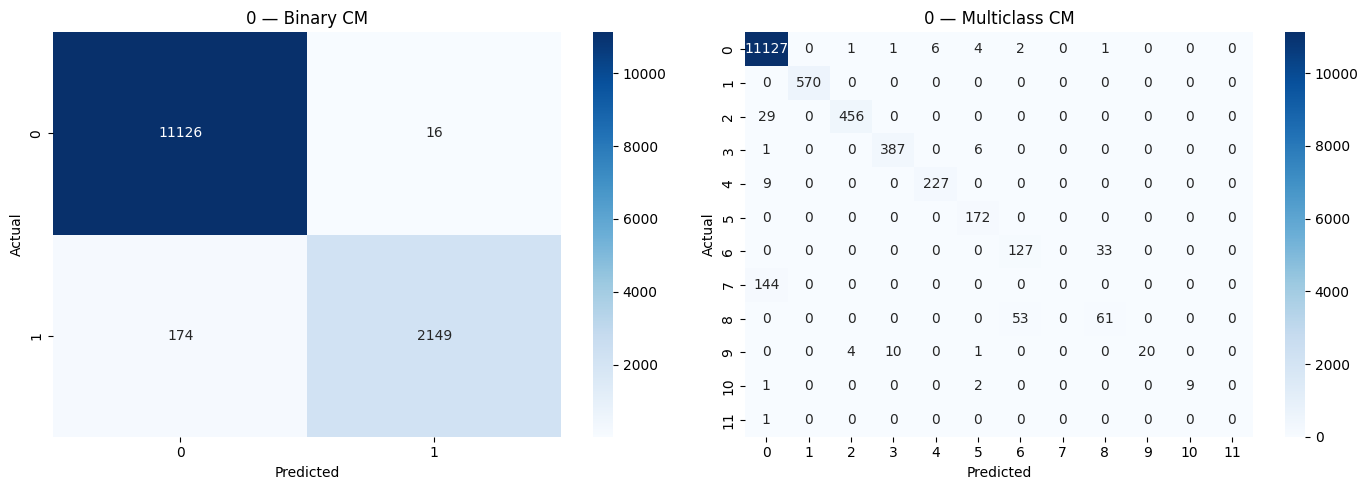


  Params: {
    "N_a": 16,
    "N_steps": 4,
    "gamma": 1.0,
    "lambda_sparse": 0.0396760507705299,
    "lr": 0.0015930522616241021,
    "batch_size": 1024,
    "mask_type": "sparsemax"
}

  Top feature importances (top 20):


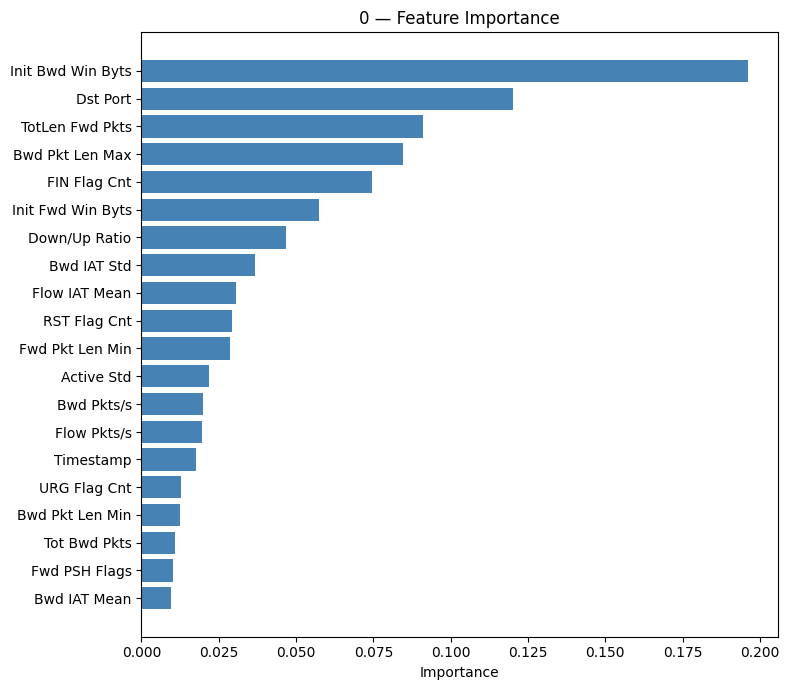


  📊  Report: CNN-LSTM — 1

  Binary Task:
    Accuracy : 0.9472
    F1-score : 0.8508
    MCC      : 0.8190
    AUC      : 0.9672

  Multiclass Task:
    Accuracy : 0.8772
    F1-score : 0.2321
    MCC      : 0.5546
    AUC      : 0.8939

  Mean MCC (binary+multi): 0.6868
  Val loss: 0.5852


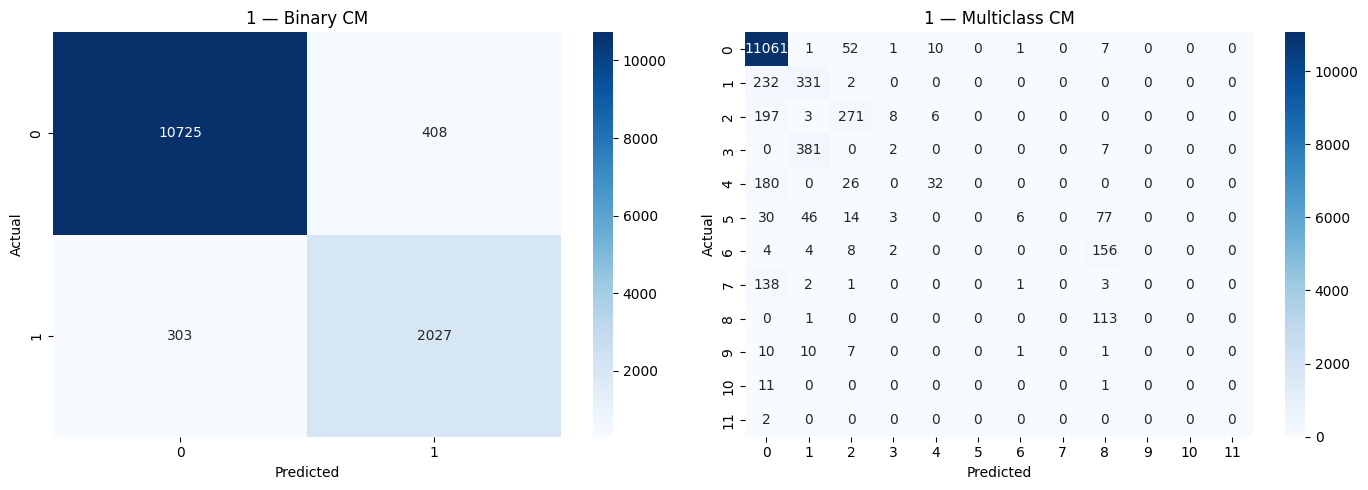


  Params: {
    "nb_filters": 32,
    "kernel_size": 3,
    "lstm_units_1": 128,
    "lstm_units_2": 256,
    "dropout": 0.1,
    "lr": 0.0016409286730647919,
    "batch_size": 1024
}

  Top feature importances (top 20):


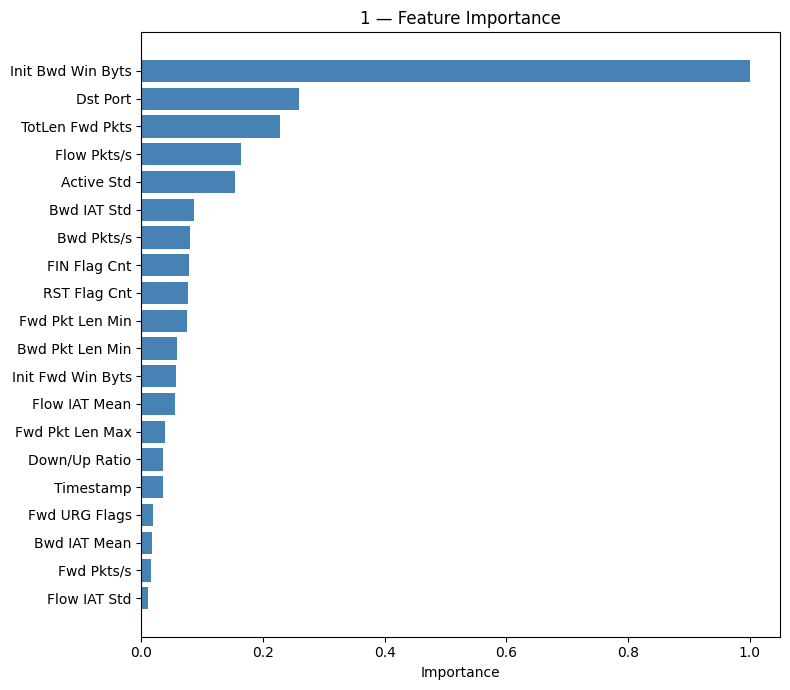

In [28]:
# TabNet — invariato
best_tabnet_trial_num = study_tabnet.best_trial.number
best_tabnet_art       = tabnet_trial_artifacts[best_tabnet_trial_num]
best_tabnet_model     = best_tabnet_art['_live_model']
print(f"✅  Best TabNet: trial {best_tabnet_trial_num} "
      f"(mean MCC={best_tabnet_art['mean_mcc']:.4f})")

# CNN-LSTM
best_cnn_lstm_trial_num = study_cnn_lstm.best_trial.number
best_cnn_lstm_art       = cnn_lstm_trial_artifacts[best_cnn_lstm_trial_num]
best_cnn_lstm_model     = best_cnn_lstm_art['_live_model']
print(f"✅  Best CNN-LSTM: trial {best_cnn_lstm_trial_num} "
      f"(mean MCC={best_cnn_lstm_art['mean_mcc']:.4f})")

# Copia best models in path canonico
import shutil
shutil.copy(f'models/tabnet_trial_{best_tabnet_trial_num}.zip',
            'models/tabnet_multitask_best.zip')
shutil.copy(f'models/cnn_lstm_trial_{best_cnn_lstm_trial_num}.pt',
            'models/cnn_lstm_multitask_best.pt')
print("💾  Saved best models to canonical paths")

# Report
show_model_report(best_tabnet_trial_num,   artifacts_dict=tabnet_trial_artifacts)
show_model_report(best_cnn_lstm_trial_num, artifacts_dict=cnn_lstm_trial_artifacts)

## Step 3: Top Feature Intersection

Take the **top 10 features** from each model (TabNet + TFT) and compute their **intersection**.  
This gives the ~8–10 features that *both* models consider most important.  
If the intersection is too small (< 5), we fall back to a combined ranking.

### Helper functions

In [29]:
def reload_all_trial_metadata(models_dir='models'):
    """
    Ripopola tabnet_trial_artifacts e cnn_lstm_trial_artifacts
    con soli metadati (no model weights in memoria).
    """
    import re

    for fname in sorted(os.listdir(models_dir)):
        if not fname.endswith('_artifacts.json'):
            continue

        match = re.match(r'(tabnet|cnn_lstm)_trial_(.+)_artifacts\.json', fname)
        if not match:
            continue

        model_type = match.group(1)
        label_str  = match.group(2)
        try:
            label = int(label_str)
        except ValueError:
            label = label_str

        with open(os.path.join(models_dir, fname)) as f:
            art = json.load(f)

        # cm: list → np.ndarray
        if art.get('cm_bin') is not None:
            art['cm_bin'] = np.array(art['cm_bin'])
        if art.get('cm_mul') is not None:
            art['cm_mul'] = np.array(art['cm_mul'])

        art['_live_model'] = None  # esplicito: modello non caricato

        if model_type == 'tabnet':
            tabnet_trial_artifacts[label] = art
        elif model_type == 'cnn_lstm':
            cnn_lstm_trial_artifacts[label] = art

    print(f"✅  Metadata reload completo:")
    print(f"    tabnet_trial_artifacts   → {len(tabnet_trial_artifacts)} trials")
    print(f"    cnn_lstm_trial_artifacts → {len(cnn_lstm_trial_artifacts)} trials")

In [30]:
# Ricarica metadati di tutti i trials
reload_all_trial_metadata()

✅  Metadata reload completo:
    tabnet_trial_artifacts   → 10 trials
    cnn_lstm_trial_artifacts → 10 trials


### Features:

In [31]:
best_tabnet_trial_num = 7

fi_tabnet = [
    k for k, v in sorted(
        tabnet_trial_artifacts[best_tabnet_trial_num]['feature_importance'].items(),
        key=lambda item: item[1],
        reverse=True
    )
]

best_tabnet = tabnet_trial_artifacts[best_tabnet_trial_num]["params"]

In [32]:
best_cnn_lstm_trial_num = 6

fi_cnn_lstm = [
    k for k, v in sorted(
        cnn_lstm_trial_artifacts[best_cnn_lstm_trial_num]['feature_importance'].items(),
        key=lambda item: item[1],
        reverse=True
    )
]

best_cnn_lstm = cnn_lstm_trial_artifacts[best_cnn_lstm_trial_num]["params"]

In [37]:
NUMNER_FEATURES_TO_RETAIN = 13

In [38]:
# ── Step 3: Top 10 Features — Intersection ────────────────────────────
top10_tabnet_features       = set(fi_tabnet[:NUMNER_FEATURES_TO_RETAIN])
top10_cnn_lstm_features     = set(fi_cnn_lstm[:NUMNER_FEATURES_TO_RETAIN])

# Intersection
IMPORTANT_FEATURES = sorted(top10_tabnet_features & top10_cnn_lstm_features)
    
print(f"📊  TabNet top {NUMNER_FEATURES_TO_RETAIN}: {sorted(top10_tabnet_features)}")
print(f"📊  CNN-LSTM top {NUMNER_FEATURES_TO_RETAIN}:    {sorted(top10_cnn_lstm_features)}")
print(f"\n🔗  Intersection ({len(IMPORTANT_FEATURES)} features):")
for f in IMPORTANT_FEATURES:
    print(f"    • {f}")

# If intersection is too small, fall back to combined importance ranking
if len(IMPORTANT_FEATURES) < 5:
    print(f"\n⚠️  Intersection too small ({len(IMPORTANT_FEATURES)}). "
          f"Using combined importance ranking instead.")

    # Normalize importances [0, 1] and sum across models
    fi_tab_norm = fi_tabnet.copy()
    fi_tab_norm['importance'] = fi_tab_norm['importance'] / fi_tab_norm['importance'].sum()
    fi_cnn_lstm_norm = fi_cnn_lstm.copy()
    fi_cnn_lstm_norm['importance'] = fi_cnn_lstm_norm['importance'] / fi_cnn_lstm_norm['importance'].sum()

    fi_combined = (
        fi_tab_norm.set_index('feature')['importance']
        .add(fi_cnn_lstm_norm.set_index('feature')['importance'], fill_value=0)
        .sort_values(ascending=False)
    )
    IMPORTANT_FEATURES = fi_combined.head(10).index.tolist()
    print(f"📊  Combined top {len(IMPORTANT_FEATURES)} features: {IMPORTANT_FEATURES}")

# Save feature list
pd.DataFrame({'feature': IMPORTANT_FEATURES}).to_csv(
    'models/important_features.csv', index=False)
print(f"\n💾  Saved: models/important_features.csv ({len(IMPORTANT_FEATURES)} features)")
print(f"\n✅  Step 3 complete: {len(IMPORTANT_FEATURES)} important features selected.")

📊  TabNet top 13: ['Down/Up Ratio', 'Dst Port', 'FIN Flag Cnt', 'Flow IAT Std', 'Flow Pkts/s', 'Fwd Pkt Len Max', 'Init Bwd Win Byts', 'Init Fwd Win Byts', 'PSH Flag Cnt', 'Protocol', 'RST Flag Cnt', 'TotLen Fwd Pkts', 'URG Flag Cnt']
📊  CNN-LSTM top 13:    ['Active Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Down/Up Ratio', 'Dst Port', 'FIN Flag Cnt', 'Flow Pkts/s', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkts/s', 'Init Bwd Win Byts', 'Init Fwd Win Byts', 'Timestamp']

🔗  Intersection (7 features):
    • Down/Up Ratio
    • Dst Port
    • FIN Flag Cnt
    • Flow Pkts/s
    • Fwd Pkt Len Max
    • Init Bwd Win Byts
    • Init Fwd Win Byts

💾  Saved: models/important_features.csv (7 features)

✅  Step 3 complete: 7 important features selected.


## Step 4: Dataset con Important Features Only

Riutilizza il dataset campionato (`PERCENTAGE_TO_USE`) → mantiene **solo le feature importanti** da Step 3.  
Lo split temporale viene applicato nei notebook di baseline/training successivi.

In [39]:
# Il temporal split è già applicato sopra — qui solo feature ridotte
print(f"📦  Baseline: {PERCENTAGE_TO_USE*100:.1f}% stratificato con feature ridotte (Step 3)")

📦  Baseline: 0.5% stratificato con feature ridotte (Step 3)


In [40]:
# ── Step 4: Dataset con sole Important Features ──────────────────────
# Riutilizziamo i dati già caricati (campione stratificato) con il subset
# di feature importanti identificate nello Step 3.

print(f"📦  Preparazione baseline dataset con {len(IMPORTANT_FEATURES)} features importanti ...")

# ── Filtra solo le feature importanti ─────────────────────────────────
BASELINE_FEATURES = [f for f in IMPORTANT_FEATURES if f in pdf_encoded.columns]
missing_feat = [f for f in IMPORTANT_FEATURES if f not in pdf_encoded.columns]
if missing_feat:
    print(f"⚠️  Feature mancanti nel dataset: {missing_feat}")

keep_cols = BASELINE_FEATURES + ['Label', 'label_generic', 'Label_enc', 'label_generic_enc']
if 'Timestamp' in pdf_encoded.columns:
    keep_cols.append('Timestamp')

pdf_baseline = pdf_encoded[[c for c in keep_cols if c in pdf_encoded.columns]].copy()

print(f"\n✅  Baseline dataset: {len(pdf_baseline):,} righe × {len(BASELINE_FEATURES)} features")
print(f"    Features: {BASELINE_FEATURES}")

# ── Salva dataset baseline ────────────────────────────────────────────
BASELINE_PATH = f'{PATH}/baseline_{pct_label}_top_features.parquet'
pdf_baseline.to_parquet(BASELINE_PATH, index=False)
print(f"💾  Saved: {BASELINE_PATH}")
print(f"\n✅  Step 4 complete.")

📦  Preparazione baseline dataset con 7 features importanti ...

✅  Baseline dataset: 80,789 righe × 7 features
    Features: ['Down/Up Ratio', 'Dst Port', 'FIN Flag Cnt', 'Flow Pkts/s', 'Fwd Pkt Len Max', 'Init Bwd Win Byts', 'Init Fwd Win Byts']
💾  Saved: DATASETS/baseline_0_5pct_top_features.parquet

✅  Step 4 complete.
